In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

print ("Setup completed.")

Setup completed.


In [13]:
ticker = "AAPL"
start_date = "2015-01-01"
end_date = "2024-12-31"

df = yf.download(ticker, start=start_date, end=end_date)

df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.192606,24.659508,23.754470,24.648443,212818400
2015-01-05,23.511061,24.042134,23.325186,23.962473,257142000
2015-01-06,23.513268,23.772165,23.152579,23.575226,263188400
2015-01-07,23.842981,23.942557,23.610636,23.721276,160423600
2015-01-08,24.759083,24.816616,24.053197,24.170477,237458000


In [14]:
print(df.info())

<class 'pandas.DataFrame'>
DatetimeIndex: 2515 entries, 2015-01-02 to 2024-12-30
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   2515 non-null   float64
 1   (High, AAPL)    2515 non-null   float64
 2   (Low, AAPL)     2515 non-null   float64
 3   (Open, AAPL)    2515 non-null   float64
 4   (Volume, AAPL)  2515 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 117.9 KB
None


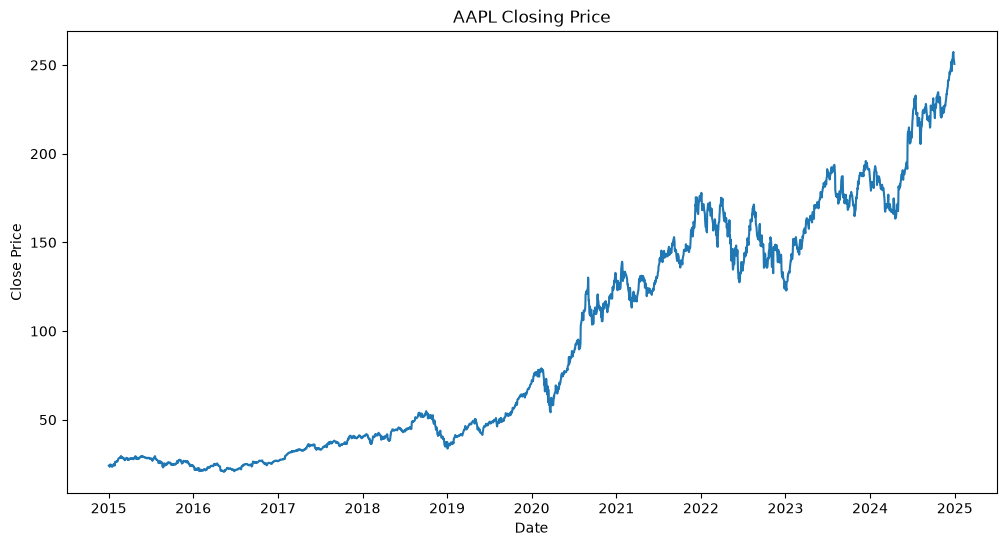

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(df["Close"])
plt.title("AAPL Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

In [16]:
close_data = df[["Close"]].copy()

print(close_data.shape)
close_data.head()

(2515, 1)


Price,Close
Ticker,AAPL
Date,
2015-01-02,24.192606
2015-01-05,23.511061
2015-01-06,23.513268
2015-01-07,23.842981
2015-01-08,24.759083


In [17]:
print(close_data.isnull().sum())

close_data = close_data.dropna()

print("Temizlenmiş veri boyutu:", close_data.shape)

Price  Ticker
Close  AAPL      0
dtype: int64
Temizlenmiş veri boyutu: (2515, 1)


In [18]:
scaler = MinMaxScaler(feature_range=(0, 1))

scaled_data = scaler.fit_transform(close_data)

print(scaled_data[:5])
print("Scaled data shape:", scaled_data.shape)

[[0.01531498]
 [0.01243696]
 [0.01244627]
 [0.01383859]
 [0.0177071 ]]
Scaled data shape: (2515, 1)


In [19]:
def create_sequences(data, sequence_length=60):
    X = []
    y = []

    for i in range(sequence_length, len(data)):
        X.append(data[i - sequence_length:i])
        y.append(data[i])

    return np.array(X), np.array(y)

In [20]:
sequence_length = 60

X, y = create_sequences(scaled_data, sequence_length)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2455, 60, 1)
y shape: (2455, 1)


In [21]:
train_size = int(len(X) * 0.80)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1964, 60, 1)
X_test: (491, 60, 1)
y_train: (1964, 1)
y_test: (491, 1)


In [22]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

print("X train tensor:", X_train_tensor.shape)
print("y train tensor:", y_train_tensor.shape)

X train tensor: torch.Size([1964, 60, 1])
y train tensor: torch.Size([1964, 1])


In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Kullanılan cihaz:", device)

Kullanılan cihaz: cpu


In [24]:
X_train_tensor = X_train_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)

y_train_tensor = y_train_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

In [25]:
class LSTMModel(nn.Module):
    def __init__(
        self,
        input_size=1,
        hidden_size=64,
        num_layers=2,
        output_size=1,
        dropout=0.2
    ):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        lstm_output, _ = self.lstm(x)

        last_output = lstm_output[:, -1, :]

        prediction = self.fc(last_output)

        return prediction

In [26]:
lstm_model = LSTMModel().to(device)

print(lstm_model)

LSTMModel(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [27]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    lstm_model.parameters(),
    lr=0.001
)

In [28]:
from torch.utils.data import TensorDataset, DataLoader

In [29]:
batch_size = 32

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Batch sayısı:", len(train_loader))

Batch sayısı: 62


In [30]:
epochs = 50
lstm_losses = []

for epoch in range(epochs):
    lstm_model.train()

    total_loss = 0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()

        predictions = lstm_model(batch_X)

        loss = criterion(predictions, batch_y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)
    lstm_losses.append(average_loss)

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch [{epoch + 1}/{epochs}], "
            f"Loss: {average_loss:.6f}"
        )

Epoch [5/50], Loss: 0.042716
Epoch [10/50], Loss: 0.000966
Epoch [15/50], Loss: 0.000830
Epoch [20/50], Loss: 0.000685
Epoch [25/50], Loss: 0.000694
Epoch [30/50], Loss: 0.000973
Epoch [35/50], Loss: 0.000996
Epoch [40/50], Loss: 0.000764
Epoch [45/50], Loss: 0.000809
Epoch [50/50], Loss: 0.001896


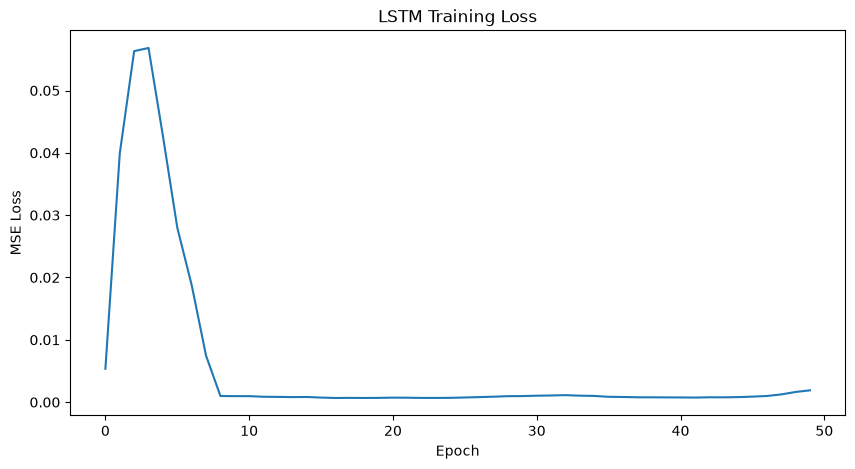

In [31]:
plt.figure(figsize=(10, 5))
plt.plot(lstm_losses)
plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

In [32]:
lstm_model.eval()

with torch.no_grad():
    lstm_predictions_scaled = lstm_model(
        X_test_tensor
    ).cpu().numpy()

In [33]:
y_test_scaled = y_test_tensor.cpu().numpy()

In [34]:
lstm_predictions = scaler.inverse_transform(
    lstm_predictions_scaled
)

actual_prices = scaler.inverse_transform(
    y_test_scaled
)

print("Tahminler:")
print(lstm_predictions[:5])

print("Gerçek fiyatlar:")
print(actual_prices[:5])

Tahminler:
[[150.48238]
 [150.83743]
 [151.0807 ]
 [151.50716]
 [152.20308]]
Gerçek fiyatlar:
[[132.95352]
 [133.01251]
 [135.56909]
 [138.75502]
 [140.15134]]


In [35]:
from sklearn.metrics import mean_absolute_error

In [36]:
lstm_mse = mean_squared_error(
    actual_prices,
    lstm_predictions
)

lstm_rmse = np.sqrt(lstm_mse)

lstm_mae = mean_absolute_error(
    actual_prices,
    lstm_predictions
)

print(f"LSTM MSE: {lstm_mse:.4f}")
print(f"LSTM RMSE: {lstm_rmse:.4f}")
print(f"LSTM MAE: {lstm_mae:.4f}")

LSTM MSE: 709.7383
LSTM RMSE: 26.6409
LSTM MAE: 20.0876


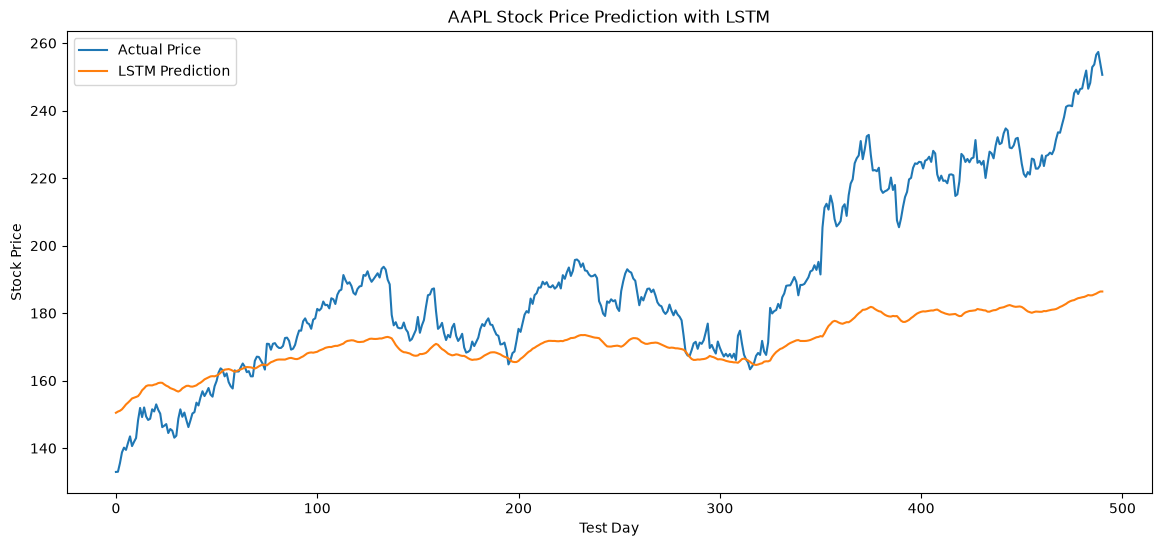

In [37]:
plt.figure(figsize=(14, 6))

plt.plot(
    actual_prices,
    label="Actual Price"
)

plt.plot(
    lstm_predictions,
    label="LSTM Prediction"
)

plt.title("AAPL Stock Price Prediction with LSTM")
plt.xlabel("Test Day")
plt.ylabel("Stock Price")
plt.legend()
plt.show()